In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/train.csv')
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [3]:
df.shape

(3000888, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [5]:
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[us]
 2   store_nbr    int64         
 3   family       str           
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 137.4 MB


In [8]:
# Fecha mínima y máxima
print("Fecha mínima:", df['date'].min())
print("Fecha máxima:", df['date'].max())

# Número de días cubiertos
print("Días cubiertos:", (df['date'].max() - df['date'].min()).days)

Fecha mínima: 2013-01-01 00:00:00
Fecha máxima: 2017-08-15 00:00:00
Días cubiertos: 1687


In [9]:
# Cuántos registros tienen ventas en 0
sales_zero = (df['sales'] == 0).sum()

print(f"Registros con ventas = 0: {sales_zero:,}")
print(f"Porcentaje: {sales_zero / len(df) * 100:.2f}%")

Registros con ventas = 0: 939,130
Porcentaje: 31.30%


In [10]:
df['sales'].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

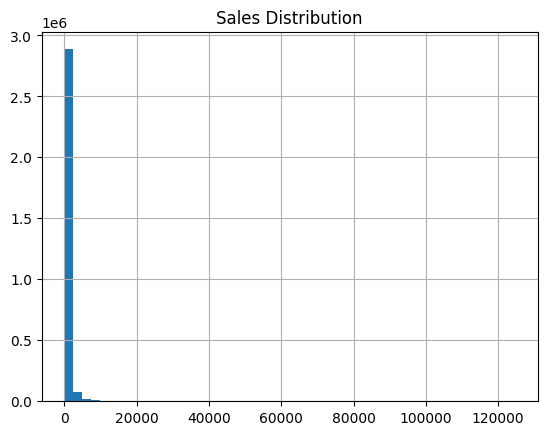

In [11]:
df['sales'].hist(bins=50)
plt.title('Sales Distribution')
plt.show()

In [12]:
# Top categorías con más ventas en cero

(
    df[df['sales'] == 0]
    .groupby('family')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

family
BOOKS                         88167
BABY CARE                     85599
SCHOOL AND OFFICE SUPPLIES    67368
HOME APPLIANCES               66854
LADIESWEAR                    54422
MAGAZINES                     51414
PET SUPPLIES                  49665
HARDWARE                      43524
LAWN AND GARDEN               42544
PLAYERS AND ELECTRONICS       40818
CELEBRATION                   39679
HOME CARE                     37201
HOME AND KITCHEN II           31567
HOME AND KITCHEN I            31505
PRODUCE                       25785
dtype: int64

In [13]:
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['store_nbr'].nunique()

54

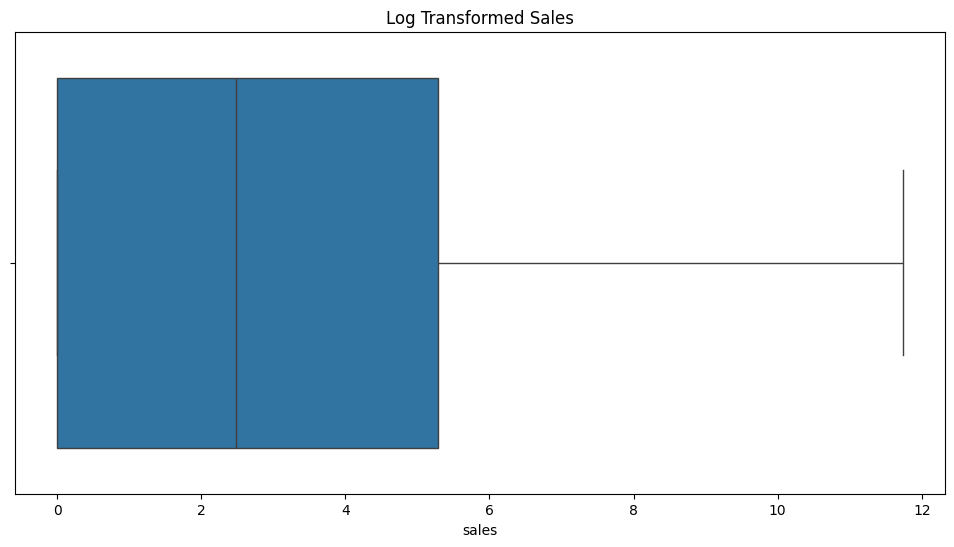

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x=np.log1p(df['sales']))
plt.title('Log Transformed Sales')
plt.show()

In [17]:
df['family'].nunique()

33

In [18]:
print(df['date'].min())
print(df['date'].max())

2013-01-01 00:00:00
2017-08-15 00:00:00


In [19]:
df.dtypes

id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object

### Data Quality Assessment

- The dataset contains 3,000,888 observations and 6 variables.
- No missing values were detected.
- No duplicate records were found.
- Sales data covers the period from January 2013 to August 2017.
- The dataset contains 54 stores and 33 product families.
- Approximately 31.3% of observations have zero sales.
- Sales are highly right-skewed, indicating the presence of large sales outliers.

# Exploratory Data Analysis (EDA)

## 1. Sales Trend Analysis

## 2. Monthly Sales Analysis

## 3. Sales by Product Family

## 4. Sales by Store

## 5. Promotion Impact Analysis

## 6. Seasonality Analysis

## 7. Key Insights

## 1. Sales Trend Analysis

In [20]:
daily_sales = (
    df.groupby('date')['sales']
      .sum()
      .reset_index()
)

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


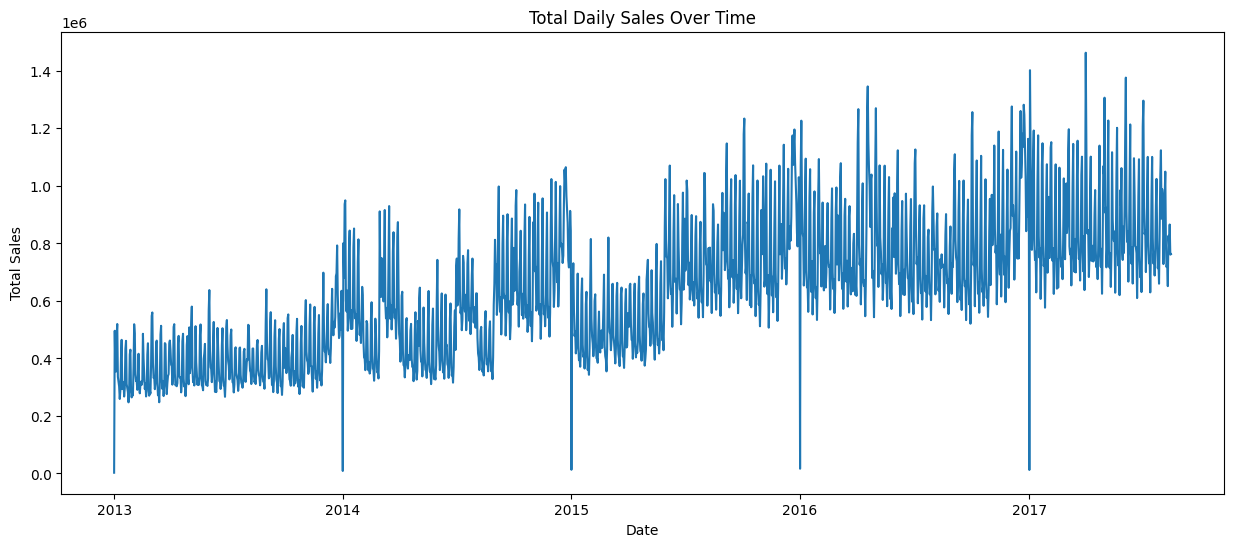

In [21]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales['date'],
    daily_sales['sales']
)

plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.show()

In [22]:
print(f"Average Daily Sales: {daily_sales['sales'].mean():,.2f}")
print(f"Median Daily Sales: {daily_sales['sales'].median():,.2f}")
print(f"Maximum Daily Sales: {daily_sales['sales'].max():,.2f}")
print(f"Minimum Daily Sales: {daily_sales['sales'].min():,.2f}")

Average Daily Sales: 637,556.38
Median Daily Sales: 632,188.86
Maximum Daily Sales: 1,463,083.96
Minimum Daily Sales: 2,511.62


In [23]:
daily_sales['rolling_30d'] = (
    daily_sales['sales']
    .rolling(window=30)
    .mean()
)

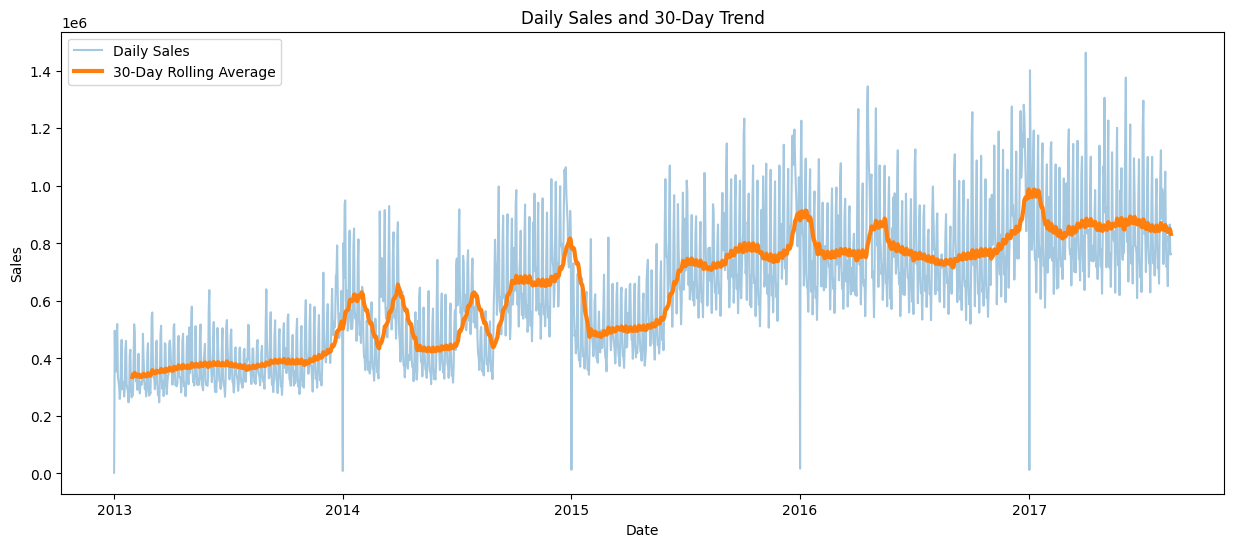

In [24]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_sales['date'],
    daily_sales['sales'],
    alpha=0.4,
    label='Daily Sales'
)

plt.plot(
    daily_sales['date'],
    daily_sales['rolling_30d'],
    linewidth=3,
    label='30-Day Rolling Average'
)

plt.title('Daily Sales and 30-Day Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.show()

### Initial Observations

- Total sales exhibit a clear upward trend from 2013 to 2017.
- The 30-day rolling average confirms sustained business growth over time.
- Sales volatility increases as total sales grow.
- Recurring peaks suggest the presence of seasonal demand patterns.
- Several isolated dates show unusually low sales values and should be investigated further.
- The dataset appears suitable for time-series forecasting due to the presence of trend and potential seasonality.

## 2. Monthly Sales Analysis

In [25]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

In [26]:
monthly_sales = (
    df.groupby(['year', 'month'])['sales']
      .sum()
      .reset_index()
)

monthly_sales.head()

,year,month,sales
0,2013,1,1.032762e+07
1,2013,2,9.658960e+06
2,2013,3,1.142850e+07
3,2013,4,1.099346e+07
4,2013,5,1.159770e+07


In [27]:
monthly_sales['year_month'] = pd.to_datetime(
    monthly_sales['year'].astype(str)
    + '-'
    + monthly_sales['month'].astype(str)
)

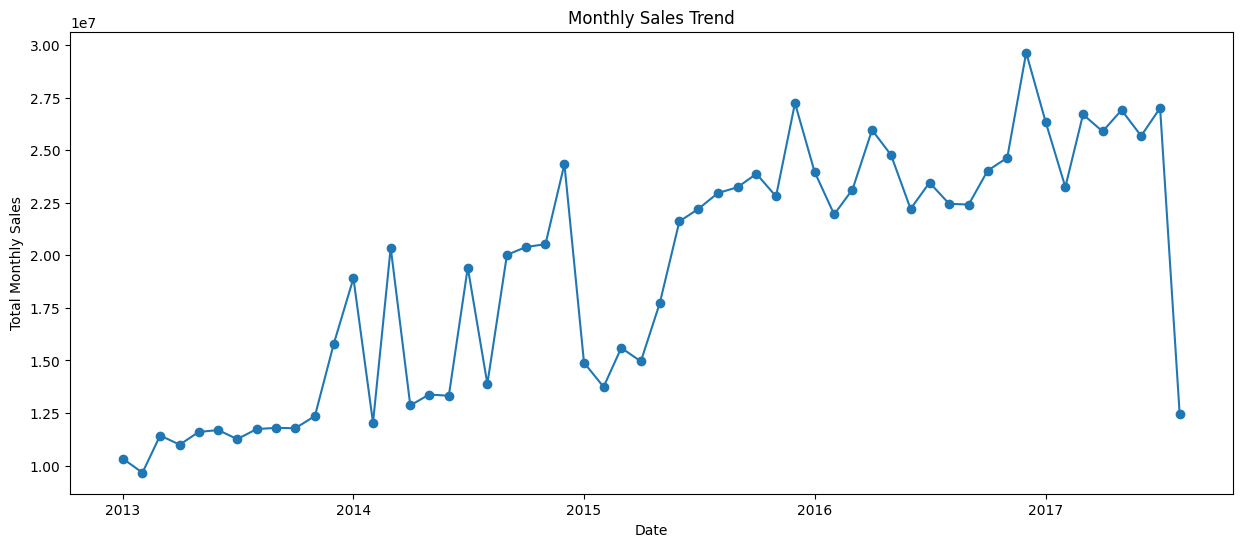

In [28]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales['year_month'],
    monthly_sales['sales'],
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Monthly Sales')

plt.show()

In [29]:
avg_month_sales = (
    df.groupby('month')['sales']
      .mean()
      .reset_index()
)

avg_month_sales

,month,sales
0,1,341.921554
1,2,320.928869
2,3,352.009294
3,4,339.199841
4,5,341.765820
5,6,353.597842
6,7,374.219111
7,8,336.992535
8,9,362.297418
9,10,362.407132


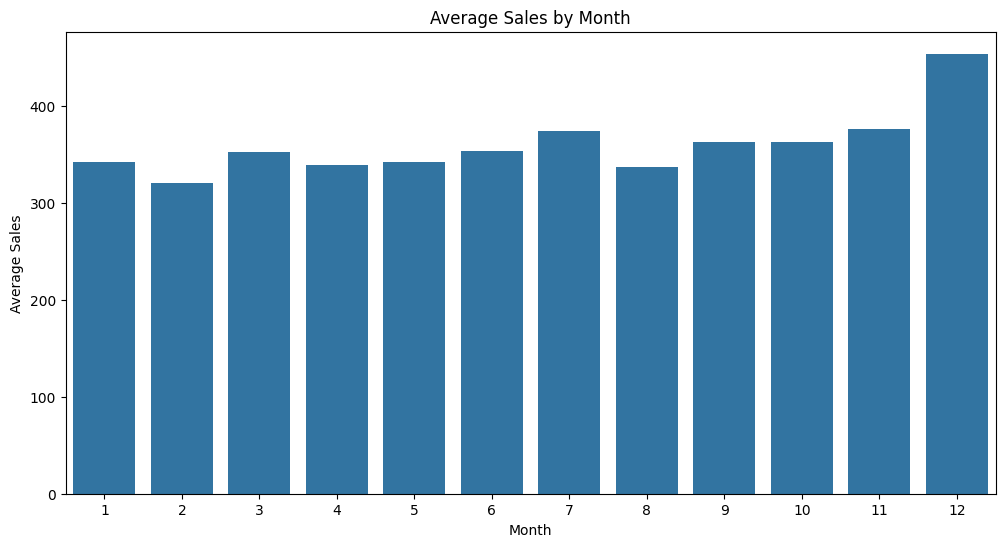

In [30]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=avg_month_sales,
    x='month',
    y='sales'
)

plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')

plt.show()

### Monthly Sales Insights

- Monthly sales show a clear upward trend from 2013 to 2017.
- A significant decline is observed during early 2015, followed by a recovery throughout the year.
- December records the highest average sales, indicating strong year-end demand.
- February has the lowest average sales across the analyzed period.
- Sales exhibit moderate seasonality, with stronger performance during the last quarter of the year.
- The results suggest that both trend and seasonality are important components of the forecasting problem.

## 3. Sales by Product Family

In [31]:
family_sales = (
    df.groupby('family')['sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

family_sales.head()

,family,sales
0,GROCERY I,3.434627e+08
1,BEVERAGES,2.169545e+08
2,PRODUCE,1.227047e+08
3,CLEANING,9.752129e+07
4,DAIRY,6.448771e+07


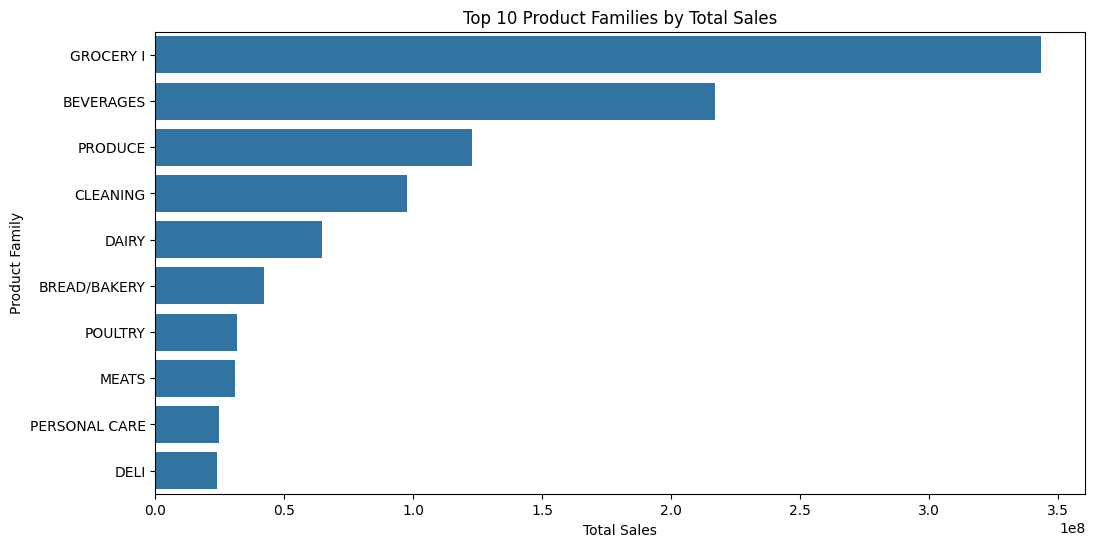

In [32]:
top_10_families = family_sales.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_families,
    x='sales',
    y='family'
)

plt.title('Top 10 Product Families by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Family')

plt.show()

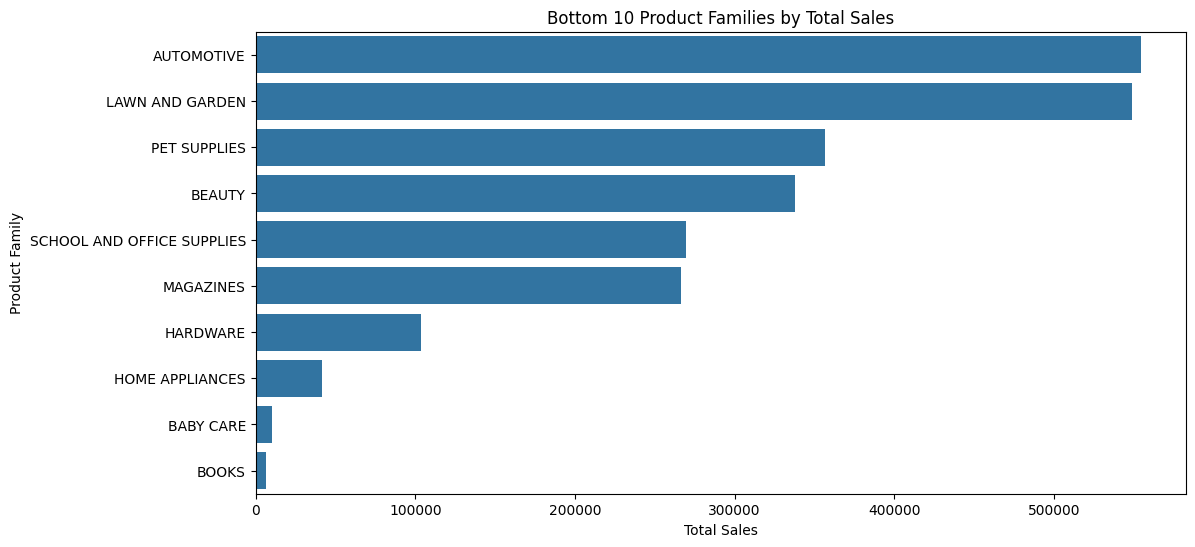

In [33]:
bottom_10_families = family_sales.tail(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom_10_families,
    x='sales',
    y='family'
)

plt.title('Bottom 10 Product Families by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Family')

plt.show()

In [34]:
top_10_share = (
    top_10_families['sales'].sum()
    / family_sales['sales'].sum()
) * 100

print(f"Top 10 families account for {top_10_share:.2f}% of total sales")

Top 10 families account for 93.04% of total sales


In [35]:
family_sales.head(1)

,family,sales
0,GROCERY I,3.434627e+08


In [36]:
family_sales.tail(1)

,family,sales
32,BOOKS,6438.0


### Product Family Insights

- Sales are highly concentrated among a small number of product families.
- The top 10 categories account for 93.04% of total sales.
- GROCERY I is the leading category by a significant margin.
- BEVERAGES and PRODUCE are the second and third largest contributors.
- Essential consumer goods dominate total sales.
- Categories such as BOOKS, BABY CARE, and HOME APPLIANCES contribute only a small fraction of total sales.
- The distribution of sales across categories is highly imbalanced.

## 4. Sales by Store

In [37]:
store_sales = (
    df.groupby('store_nbr')['sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

store_sales.head()

,store_nbr,sales
0,44,6.208755e+07
1,45,5.449801e+07
2,47,5.094831e+07
3,3,5.048191e+07
4,49,4.342010e+07


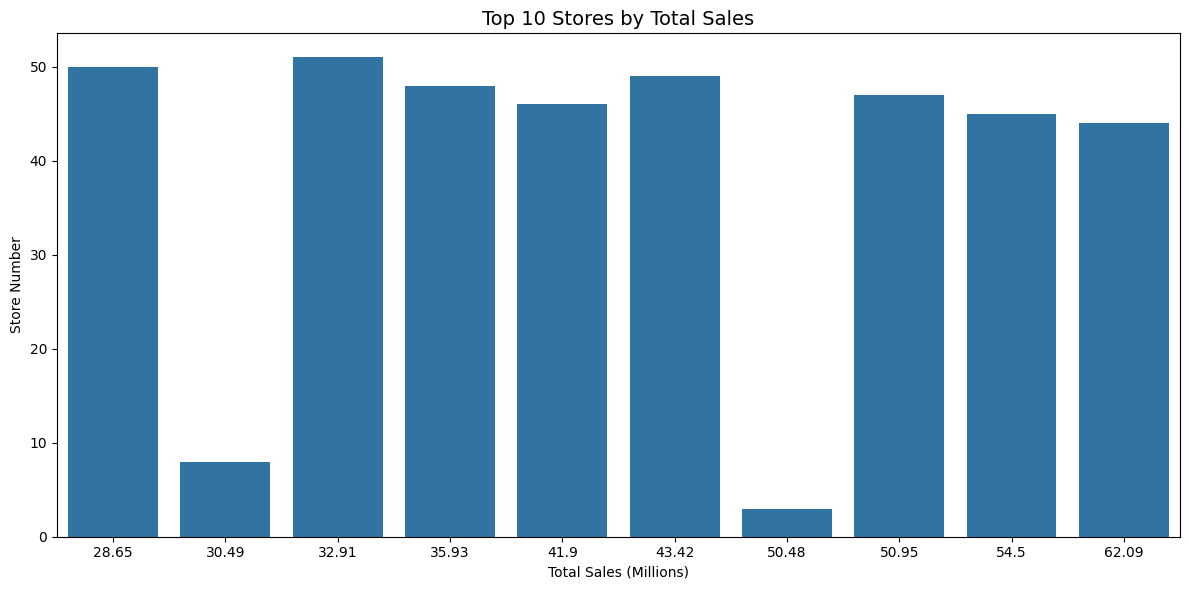

In [38]:
top_10_stores = store_sales.head(10).copy()

top_10_stores['sales_million'] = (
    top_10_stores['sales'] / 1_000_000
).round(2)
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_stores,
    x='sales_million',
    y='store_nbr'
)

plt.title('Top 10 Stores by Total Sales', fontsize=14)
plt.xlabel('Total Sales (Millions)')
plt.ylabel('Store Number')

plt.tight_layout()
plt.show()

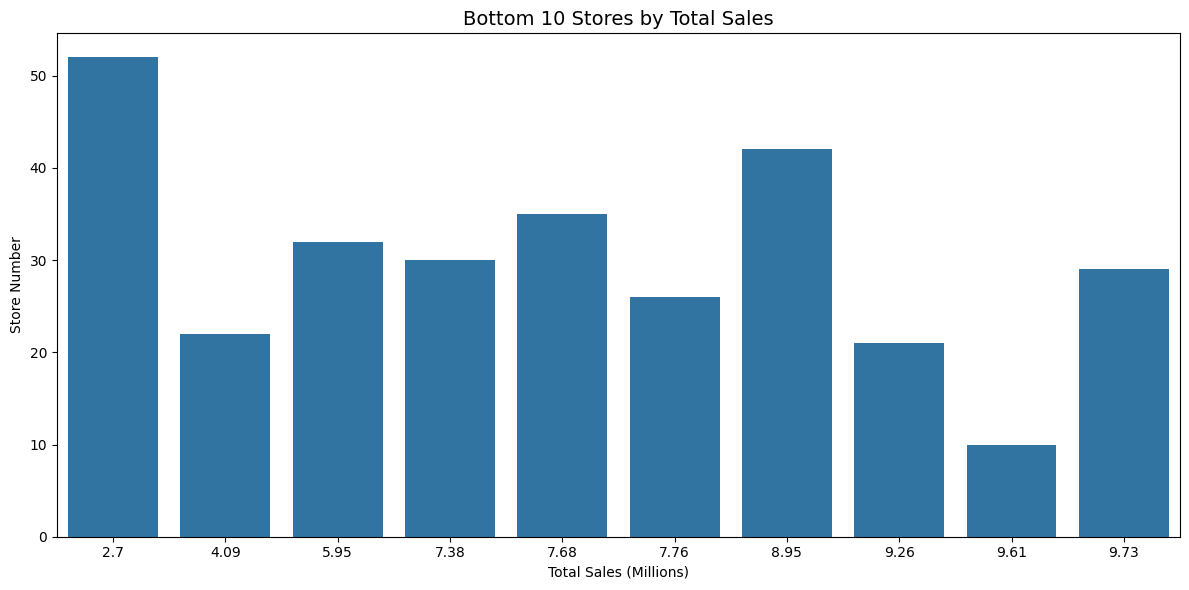

In [39]:
bottom_10_stores = store_sales.tail(10).copy()

bottom_10_stores['sales_million'] = (
    bottom_10_stores['sales'] / 1_000_000
).round(2)

plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom_10_stores,
    x='sales_million',
    y='store_nbr'
)

plt.title('Bottom 10 Stores by Total Sales', fontsize=14)
plt.xlabel('Total Sales (Millions)')
plt.ylabel('Store Number')

plt.tight_layout()
plt.show()

In [40]:
store_sales['sales_million'] = (
    store_sales['sales'] / 1_000_000
).round(2)

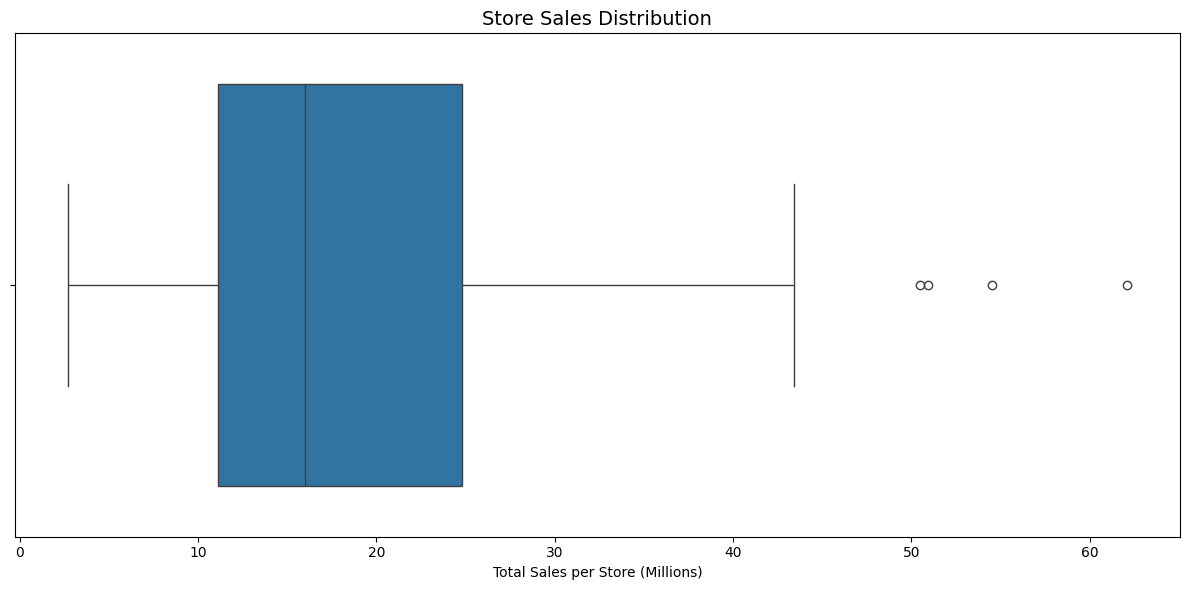

In [41]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=store_sales['sales_million']
)

plt.title('Store Sales Distribution', fontsize=14)
plt.xlabel('Total Sales per Store (Millions)')

plt.tight_layout()
plt.show()

In [42]:
top_10_store_share = (
    top_10_stores['sales'].sum()
    / store_sales['sales'].sum()
) * 100

print(
    f"Top 10 stores account for {top_10_store_share:.2f}% of total sales"
)

Top 10 stores account for 40.17% of total sales


In [43]:
store_sales.tail(1)

,store_nbr,sales,sales_million
53,52,2.696170e+06,2.7


### Store Distribution Insights

- The median store generates approximately 16 million in total sales.
- Half of the stores generate between 11 and 25 million in sales.
- Most stores operate within a relatively similar sales range.
- Several high-performing stores appear as outliers, generating significantly more sales than the rest.
- No extreme low-performing stores were identified.
- Sales concentration across stores is substantially lower than sales concentration across product families.

## 5. Promotion Impact Analysis

In [44]:
df['has_promotion'] = df['onpromotion'] > 0

In [45]:
promotion_impact = (
    df.groupby('has_promotion')['sales']
      .mean()
      .reset_index()
)

promotion_impact

,has_promotion,sales
0,False,158.246681
1,True,1137.693730


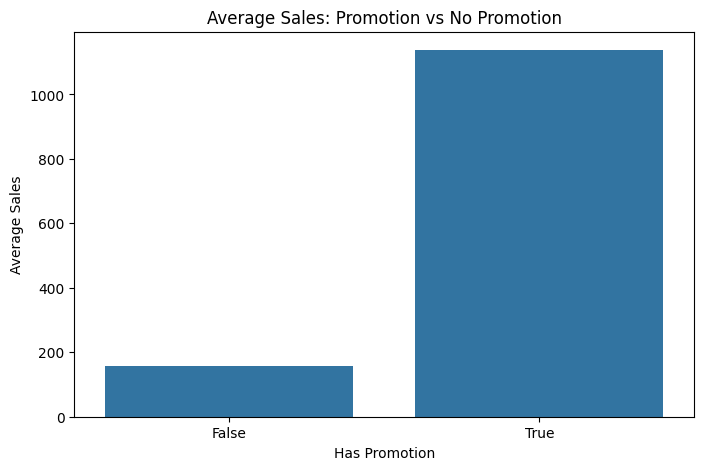

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=promotion_impact,
    x='has_promotion',
    y='sales'
)

plt.title('Average Sales: Promotion vs No Promotion')
plt.xlabel('Has Promotion')
plt.ylabel('Average Sales')

plt.show()

In [47]:
df['has_promotion'].value_counts()

has_promotion
False    2389559
True      611329
Name: count, dtype: int64

In [48]:
promotion_pct = (
    df['has_promotion']
    .value_counts(normalize=True)
    * 100
)

print(promotion_pct)

has_promotion
False    79.628397
True     20.371603
Name: proportion, dtype: float64


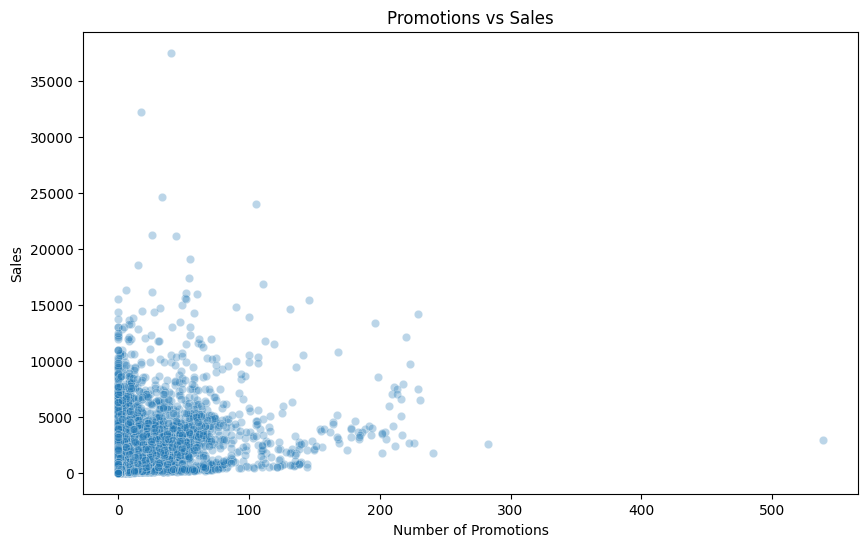

In [49]:
sample_df = df.sample(50000, random_state=42)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x='onpromotion',
    y='sales',
    alpha=0.3
)

plt.title('Promotions vs Sales')
plt.xlabel('Number of Promotions')
plt.ylabel('Sales')

plt.show()

In [50]:
print(
    df['sales'].corr(df['onpromotion'])
)

0.42792320481213236


### Promotion Impact Insights

- Products under promotion generate substantially higher average sales than non-promoted products.
- Average sales are approximately seven times higher when promotions are active.
- The correlation between promotions and sales is 0.43, indicating a moderate positive relationship.
- Promotions appear to be an important sales driver, although other factors also influence demand.
- The results suggest that promotion-related features should be included in forecasting models.

In [51]:
family_promo = (
    df.groupby(['family', 'has_promotion'])['sales']
      .mean()
      .reset_index()
)

family_promo.head()

,family,has_promotion,sales
0,AUTOMOTIVE,False,5.853087
1,AUTOMOTIVE,True,13.241978
2,BABY CARE,False,0.109624
3,BABY CARE,True,1.660377
4,BEAUTY,False,3.078452


In [52]:
family_promo_pivot = (
    family_promo
    .pivot(
        index='family',
        columns='has_promotion',
        values='sales'
    )
    .reset_index()
)

family_promo_pivot.columns = [
    'family',
    'without_promotion',
    'with_promotion'
]

family_promo_pivot.head()

,family,without_promotion,with_promotion
0,AUTOMOTIVE,5.853087,13.241978
1,BABY CARE,0.109624,1.660377
2,BEAUTY,3.078452,8.291266
3,BEVERAGES,1292.272591,3215.498308
4,BOOKS,0.070797,NaN


In [53]:
family_promo_pivot['sales_increase'] = (
    family_promo_pivot['with_promotion']
    - family_promo_pivot['without_promotion']
)

family_promo_pivot.sort_values(
    'sales_increase',
    ascending=False
).head(10)

,family,without_promotion,with_promotion,sales_increase
3,BEVERAGES,1292.272591,3215.498308,1923.225717
12,GROCERY I,2717.720813,4411.003431,1693.282618
30,PRODUCE,792.101911,2438.220197,1646.118286
8,DAIRY,479.811128,933.341720,453.530592
7,CLEANING,868.378326,1240.210741,371.832415
18,HOME CARE,101.956009,309.444864,207.488856
5,BREAD/BAKERY,379.513249,575.485296,195.972047
28,POULTRY,313.334513,485.006113,171.671600
24,MEATS,303.081088,467.301631,164.220543
11,FROZEN FOODS,106.524349,228.997534,122.473185


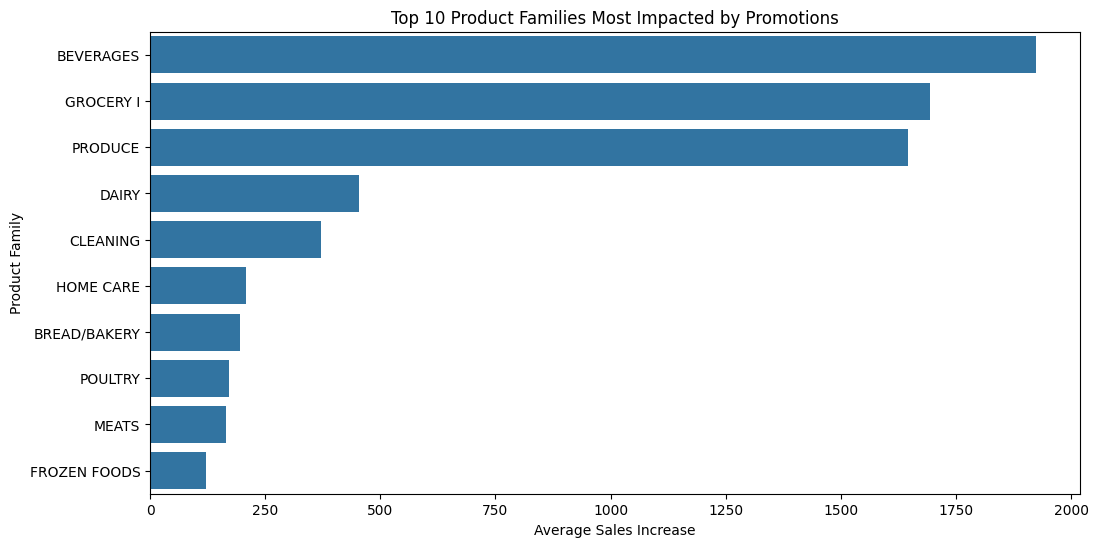

In [54]:
top_promo_effect = (
    family_promo_pivot
    .sort_values(
        'sales_increase',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_promo_effect,
    x='sales_increase',
    y='family'
)

plt.title(
    'Top 10 Product Families Most Impacted by Promotions'
)

plt.xlabel(
    'Average Sales Increase'
)

plt.ylabel(
    'Product Family'
)

plt.show()

In [55]:
family_promo_pivot['increase_pct'] = (
    (
        family_promo_pivot['with_promotion']
        - family_promo_pivot['without_promotion']
    )
    /
    family_promo_pivot['without_promotion']
) * 100

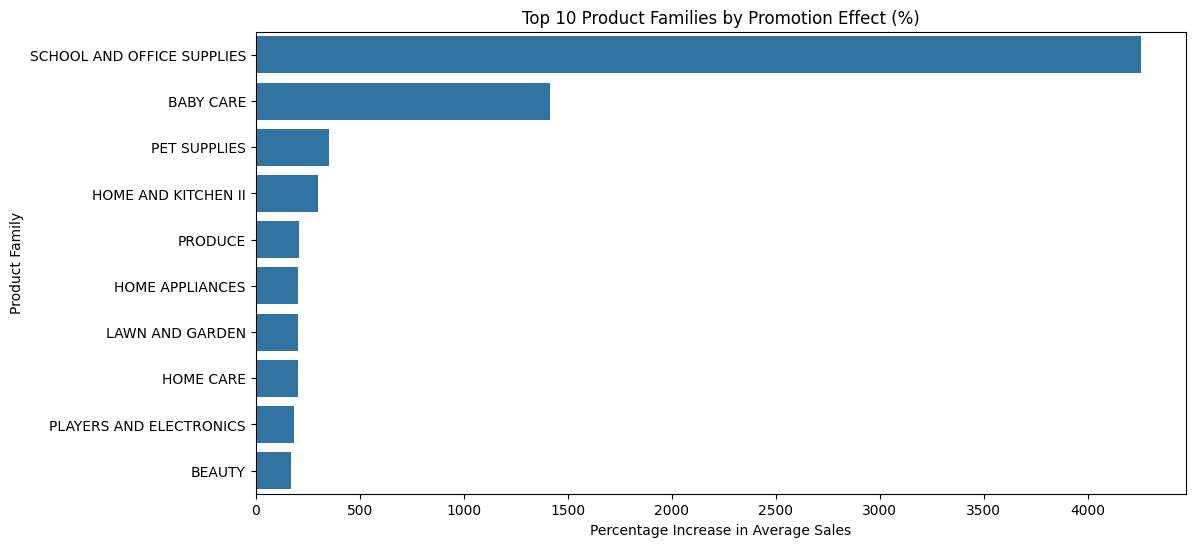

In [56]:
top_pct_effect = (
    family_promo_pivot
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(
        'increase_pct',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_pct_effect,
    x='increase_pct',
    y='family'
)

plt.title(
    'Top 10 Product Families by Promotion Effect (%)'
)

plt.xlabel(
    'Percentage Increase in Average Sales'
)

plt.ylabel(
    'Product Family'
)

plt.show()

In [57]:
family_promo_pivot[
    family_promo_pivot['family']
    == 'SCHOOL AND OFFICE SUPPLIES'
]

,family,without_promotion,with_promotion,sales_increase,increase_pct
31,SCHOOL AND OFFICE SUPPLIES,1.022018,44.529107,43.507089,4256.977171


In [58]:
family_promo_pivot.sort_values(
    'increase_pct',
    ascending=False
).head(10)

,family,without_promotion,with_promotion,sales_increase,increase_pct
31,SCHOOL AND OFFICE SUPPLIES,1.022018,44.529107,43.507089,4256.977171
1,BABY CARE,0.109624,1.660377,1.550753,1414.604792
26,PET SUPPLIES,3.507379,15.835244,12.327865,351.483670
16,HOME AND KITCHEN II,10.275239,41.158133,30.882894,300.556454
30,PRODUCE,792.101911,2438.220197,1646.118286,207.816477
17,HOME APPLIANCES,0.456876,1.396552,0.939675,205.673959
20,LAWN AND GARDEN,5.510703,16.786862,11.276159,204.622872
18,HOME CARE,101.956009,309.444864,207.488856,203.508217
27,PLAYERS AND ELECTRONICS,6.081521,17.363958,11.282436,185.519972
2,BEAUTY,3.078452,8.291266,5.212813,169.332258


### Promotion Effect by Product Family

- High-volume categories such as BEVERAGES, GROCERY I and PRODUCE generate the largest absolute sales gains during promotional periods.
- Categories such as SCHOOL AND OFFICE SUPPLIES and BABY CARE show the highest percentage increases.
- The extremely high percentage increases are driven by very low baseline sales levels.
- Promotion effectiveness should be evaluated using both absolute and relative metrics.
- For revenue generation, promotions appear most valuable in high-volume categories.
- For customer responsiveness, smaller categories exhibit the strongest relative reaction.

## 6. Seasonality Analysis

In [59]:
df['day_of_week'] = df['date'].dt.day_name()
df['month_name'] = df['date'].dt.month_name()

In [60]:
weekday_sales = (
    df.groupby('day_of_week')['sales']
      .mean()
      .reset_index()
)

In [61]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_sales['day_of_week'] = pd.Categorical(
    weekday_sales['day_of_week'],
    categories=weekday_order,
    ordered=True
)

weekday_sales = weekday_sales.sort_values(
    'day_of_week'
)

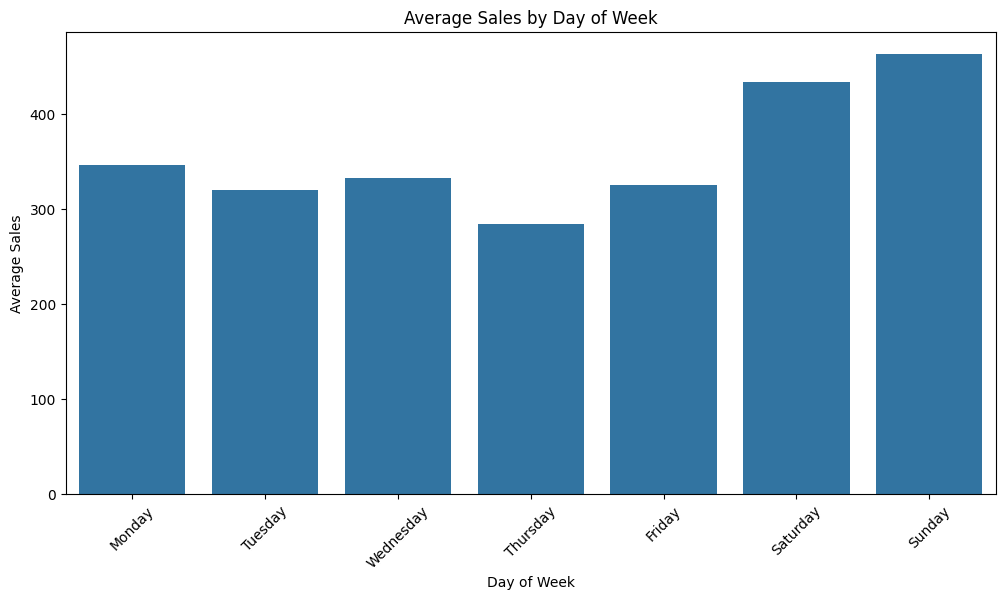

In [62]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=weekday_sales,
    x='day_of_week',
    y='sales'
)

plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')

plt.xticks(rotation=45)

plt.show()

In [63]:
monthly_heatmap = (
    df.groupby([
        df['date'].dt.year,
        df['date'].dt.month
    ])['sales']
    .mean()
    .unstack()
)

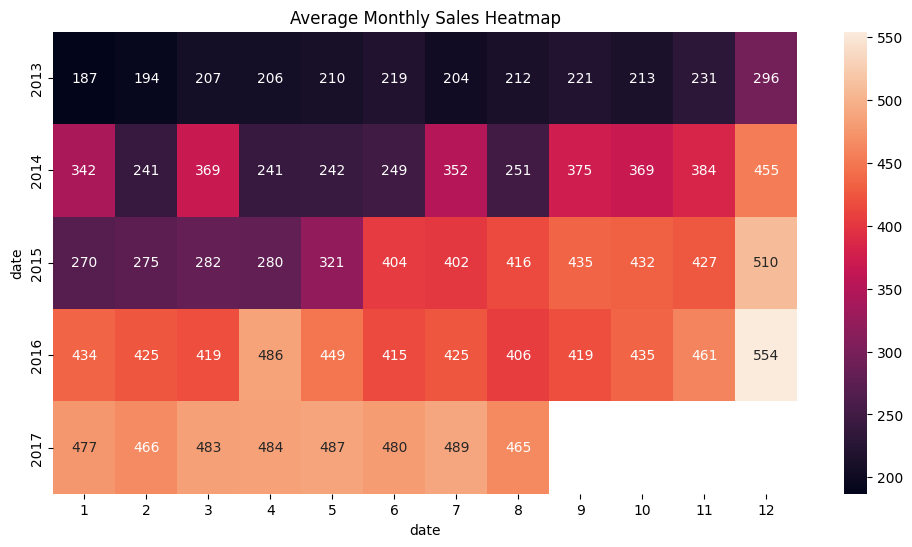

In [64]:
plt.figure(figsize=(12,6))

sns.heatmap(
    monthly_heatmap,
    annot=True,
    fmt='.0f'
)

plt.title('Average Monthly Sales Heatmap')

plt.show()

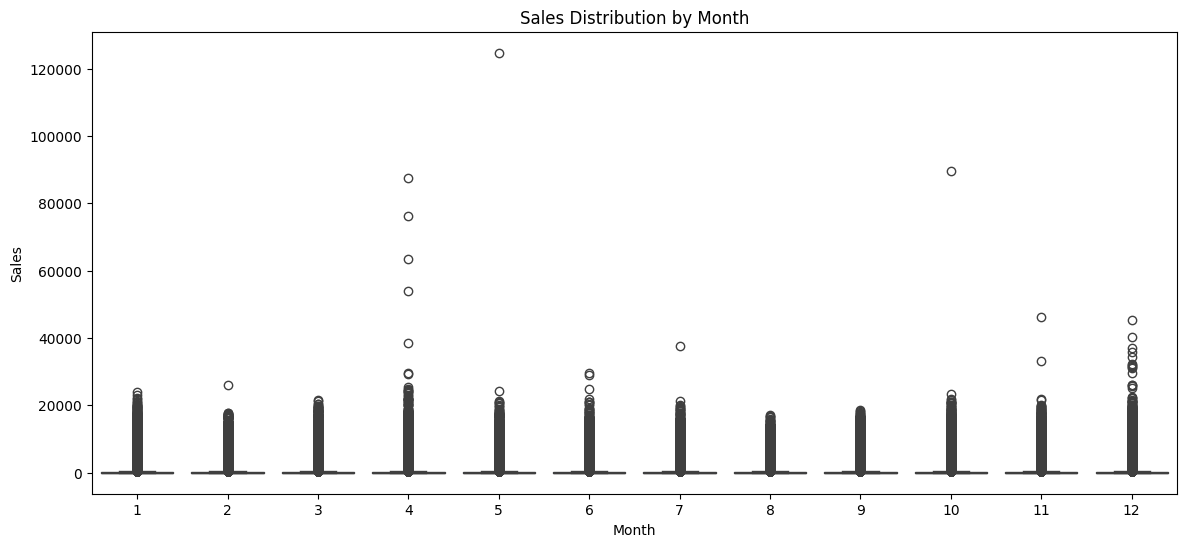

In [65]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x=df['date'].dt.month,
    y='sales'
)

plt.title('Sales Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

### Seasonality Insights

- Weekend sales are noticeably higher than weekday sales, with Sunday showing the highest average sales.
- The heatmap confirms the long-term growth trend observed in previous analyses.
- December consistently appears among the strongest performing months.
- Monthly sales distributions show substantial variability and several extreme sales events.
- Overall, the results reinforce the presence of both trend and seasonality in the dataset.

## 7. Key Insights

In [66]:
df_features = df.copy()

In [67]:
df_features['year'] = df_features['date'].dt.year
df_features['month'] = df_features['date'].dt.month
df_features['day'] = df_features['date'].dt.day
df_features['day_of_week'] = df_features['date'].dt.dayofweek
df_features['quarter'] = df_features['date'].dt.quarter
df_features['week_of_year'] = df_features['date'].dt.isocalendar().week.astype(int)

In [68]:
df_features['is_weekend'] = (
    df_features['day_of_week'] >= 5
).astype(int)

In [69]:
import numpy as np

df_features['month_sin'] = np.sin(
    2 * np.pi * df_features['month'] / 12
)

df_features['month_cos'] = np.cos(
    2 * np.pi * df_features['month'] / 12
)

In [70]:
df_features['has_promotion'] = (
    df_features['onpromotion'] > 0
).astype(int)

In [71]:
df_features.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,has_promotion,day_of_week,month_name,day,quarter,week_of_year,is_weekend,month_sin,month_cos
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,0,1,January,1,1,1,0,0.5,0.866025
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,0,1,January,1,1,1,0,0.5,0.866025
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,0,1,January,1,1,1,0,0.5,0.866025
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,0,1,January,1,1,1,0,0.5,0.866025
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,0,1,January,1,1,1,0,0.5,0.866025


In [72]:
feature_cols = [
    'year',
    'month',
    'day',
    'day_of_week',
    'quarter',
    'week_of_year',
    'is_weekend',
    'month_sin',
    'month_cos',
    'has_promotion'
]

df_features[feature_cols].head()

,year,month,day,day_of_week,quarter,week_of_year,is_weekend,month_sin,month_cos,has_promotion
0,2013,1,1,1,1,1,0,0.5,0.866025,0
1,2013,1,1,1,1,1,0,0.5,0.866025,0
2,2013,1,1,1,1,1,0,0.5,0.866025,0
3,2013,1,1,1,1,1,0,0.5,0.866025,0
4,2013,1,1,1,1,1,0,0.5,0.866025,0


In [73]:
daily_forecast = (
    df.groupby('date')['sales']
      .sum()
      .reset_index()
)

daily_forecast.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [74]:
daily_forecast['year'] = daily_forecast['date'].dt.year
daily_forecast['month'] = daily_forecast['date'].dt.month
daily_forecast['day_of_week'] = daily_forecast['date'].dt.dayofweek
daily_forecast['quarter'] = daily_forecast['date'].dt.quarter
daily_forecast['week_of_year'] = (
    daily_forecast['date']
    .dt.isocalendar()
    .week
    .astype(int)
)

daily_forecast['is_weekend'] = (
    daily_forecast['day_of_week'] >= 5
).astype(int)

In [75]:
daily_forecast['lag_1'] = (
    daily_forecast['sales']
    .shift(1)
)

In [76]:
daily_forecast['lag_7'] = (
    daily_forecast['sales']
    .shift(7)
)

In [77]:
daily_forecast['lag_30'] = (
    daily_forecast['sales']
    .shift(30)
)

In [78]:
daily_forecast[
    [
        'date',
        'sales',
        'lag_1',
        'lag_7',
        'lag_30'
    ]
].head(35)

,date,sales,lag_1,lag_7,lag_30
0,2013-01-01,2511.618999,NaN,NaN,NaN
1,2013-01-02,496092.417944,2511.618999,NaN,NaN
2,2013-01-03,361461.231124,496092.417944,NaN,NaN
3,2013-01-04,354459.677093,361461.231124,NaN,NaN
4,2013-01-05,477350.121229,354459.677093,NaN,NaN
5,2013-01-06,519695.401088,477350.121229,NaN,NaN
6,2013-01-07,336122.801066,519695.401088,NaN,NaN
7,2013-01-08,318347.777981,336122.801066,2511.618999,NaN
8,2013-01-09,302530.809018,318347.777981,496092.417944,NaN
9,2013-01-10,258982.003049,302530.809018,361461.231124,NaN


In [79]:
daily_forecast['rolling_mean_7'] = (
    daily_forecast['sales']
    .rolling(window=7)
    .mean()
)

In [80]:
daily_forecast['rolling_mean_30'] = (
    daily_forecast['sales']
    .rolling(window=30)
    .mean()
)

In [81]:
daily_forecast.head(5)

,date,sales,year,month,day_of_week,quarter,week_of_year,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,2013-01-01,2511.618999,2013,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,496092.417944,2013,1,2,1,1,0,2511.618999,NaN,NaN,NaN,NaN
2,2013-01-03,361461.231124,2013,1,3,1,1,0,496092.417944,NaN,NaN,NaN,NaN
3,2013-01-04,354459.677093,2013,1,4,1,1,0,361461.231124,NaN,NaN,NaN,NaN
4,2013-01-05,477350.121229,2013,1,5,1,1,1,354459.677093,NaN,NaN,NaN,NaN


In [82]:
daily_forecast.isnull().sum()

date                0
sales               0
year                0
month               0
day_of_week         0
quarter             0
week_of_year        0
is_weekend          0
lag_1               1
lag_7               7
lag_30             30
rolling_mean_7      6
rolling_mean_30    29
dtype: int64

In [83]:
daily_forecast = daily_forecast.dropna()

In [84]:
daily_forecast.shape

(1654, 13)

In [85]:
corr_df = daily_forecast[
    [
        'sales',
        'year',
        'month',
        'day_of_week',
        'quarter',
        'week_of_year',
        'is_weekend',
        'lag_1',
        'lag_7',
        'lag_30',
        'rolling_mean_7',
        'rolling_mean_30'
    ]
]

In [86]:
corr_matrix = corr_df.corr()

corr_matrix

,sales,year,month,day_of_week,quarter,week_of_year,is_weekend,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
sales,1.000000,0.670120,0.134993,0.311179,0.126831,0.105893,0.439670,0.762033,0.822785,0.485563,0.802418,0.769530
year,0.670120,1.000000,-0.188644,-0.001643,-0.175778,-0.180558,-0.001090,0.672168,0.682786,0.713036,0.829675,0.890300
month,0.134993,-0.188644,1.000000,-0.007177,0.969870,0.964280,-0.001996,0.129472,0.083978,-0.029843,0.141624,0.038510
day_of_week,0.311179,-0.001643,-0.007177,1.000000,-0.005286,-0.004894,0.790642,-0.096428,0.307130,-0.367528,-0.004431,0.004751
quarter,0.126831,-0.175778,0.969870,-0.005286,1.000000,0.939813,-0.001453,0.120361,0.085510,-0.002601,0.135038,0.054370
week_of_year,0.105893,-0.180558,0.964280,-0.004894,0.939813,1.000000,-0.001595,0.115986,0.070966,-0.032536,0.126657,0.039358
is_weekend,0.439670,-0.001090,-0.001996,0.790642,-0.001453,-0.001595,1.000000,0.103867,0.434589,-0.251133,-0.000971,0.020995
lag_1,0.762033,0.672168,0.129472,-0.096428,0.120361,0.115986,0.103867,1.000000,0.692526,0.645902,0.815055,0.774977
lag_7,0.822785,0.682786,0.083978,0.307130,0.085510,0.070966,0.434589,0.692526,1.000000,0.458873,0.772828,0.795147
lag_30,0.485563,0.713036,-0.029843,-0.367528,-0.002601,-0.032536,-0.251133,0.645902,0.458873,1.000000,0.683990,0.752900


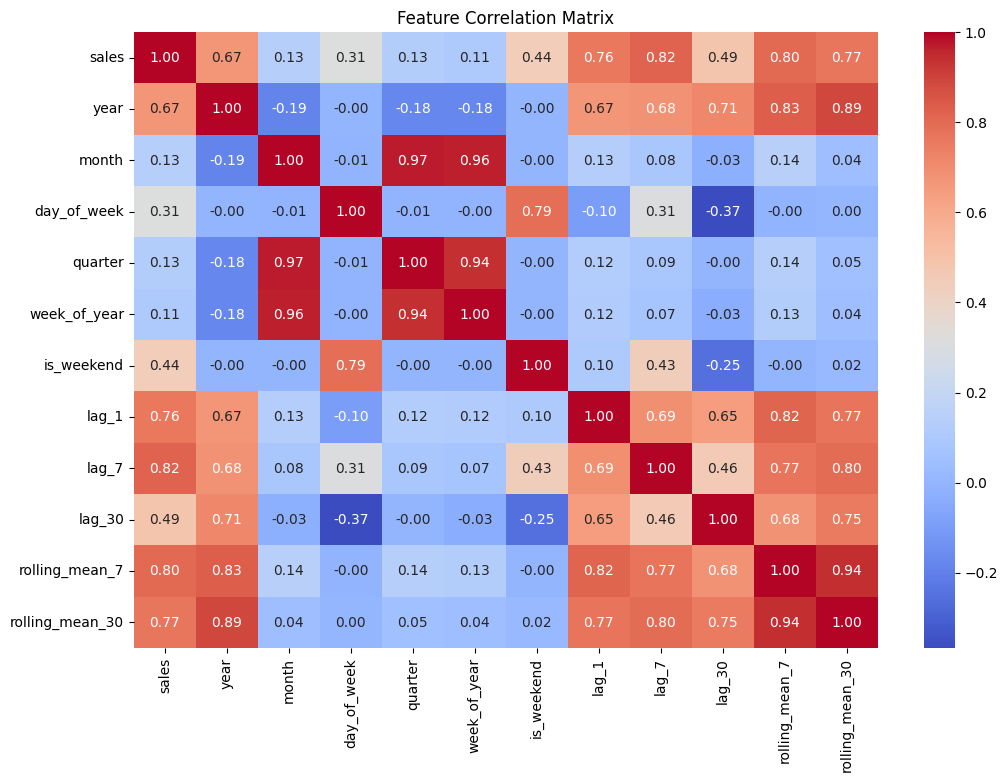

In [87]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Matrix')

plt.show()

In [88]:
sales_corr = (
    corr_matrix['sales']
    .sort_values(ascending=False)
)

sales_corr

sales              1.000000
lag_7              0.822785
rolling_mean_7     0.802418
rolling_mean_30    0.769530
lag_1              0.762033
year               0.670120
lag_30             0.485563
is_weekend         0.439670
day_of_week        0.311179
month              0.134993
quarter            0.126831
week_of_year       0.105893
Name: sales, dtype: float64

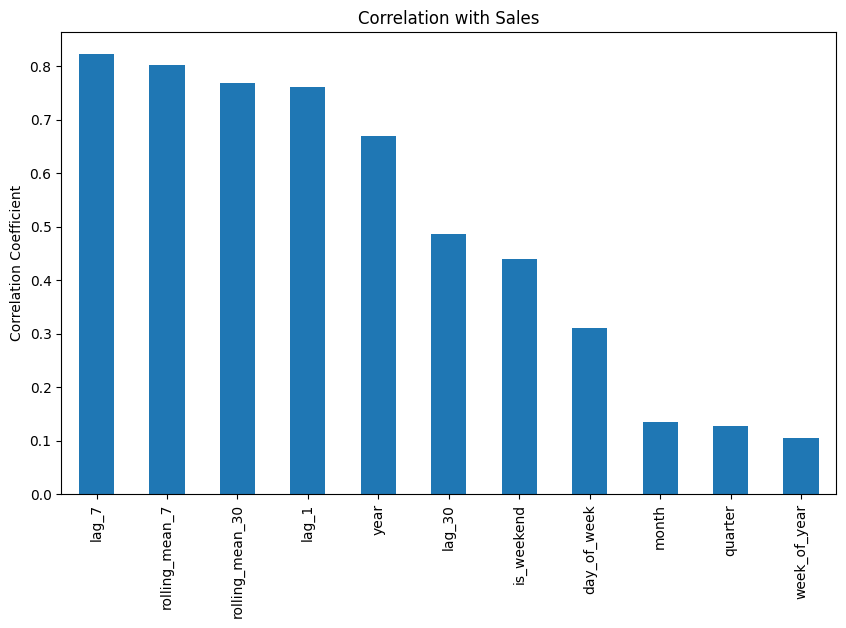

In [89]:
plt.figure(figsize=(10,6))

sales_corr.drop('sales').plot(
    kind='bar'
)

plt.title(
    'Correlation with Sales'
)

plt.ylabel(
    'Correlation Coefficient'
)

plt.show()

Correlation analysis revealed that lag-based features were the strongest predictors of sales. Sales from the previous week (lag_7) showed the highest correlation (0.82), followed by rolling averages and lag_1. Calendar features such as month and quarter exhibited relatively weak relationships, suggesting that recent sales history is substantially more informative than calendar position for forecasting demand.